## CUTIX STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

cutix=pd.read_csv('../stock_data/cutix.csv') ## so it can be small letter. This is cool.
cutix=cutix.drop(columns=['high_price','low_price'])
cutix.rename(columns={'trade_date':'date'},inplace=True)
cutix['date']=pd.to_datetime(cutix['date'])
cutix['month']=cutix['date'].dt.month
cutix['quarter']=cutix['date'].dt.quarter
cutix['year']=cutix['date'].dt.year

cutix

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42846,CUTIX,2017-01-03,1.89,1.89,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43406,CUTIX,2017-01-04,1.89,1.89,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43516,CUTIX,2017-01-05,1.89,1.89,16126,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43626,CUTIX,2017-01-06,1.89,1.89,15000,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43716,CUTIX,2017-01-09,1.89,1.89,500,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298047,CUTIX,2026-07-13,2.80,2.80,5847098,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298485,CUTIX,2026-07-14,2.80,2.80,1669210,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298923,CUTIX,2026-07-15,2.92,2.92,2057304,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299361,CUTIX,2026-07-16,2.98,2.98,1754700,2026-07-16T15:10:03.113936+00:00,7,3,2026


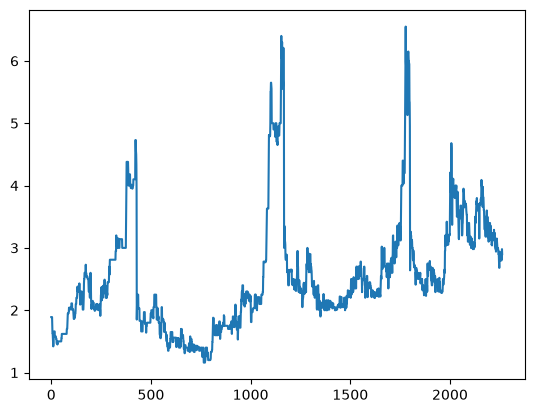

In [2]:
import matplotlib.pyplot as plt

plt.plot(cutix['close_price'])
plt.show()

In [3]:
cutix_end_month_df = (
    cutix
    .sort_values("date")
    .groupby(cutix["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

cutix_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45416,CUTIX,2017-01-31,1.58,1.58,14200,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47238,CUTIX,2017-02-28,1.50,1.50,19000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49354,CUTIX,2017-03-31,1.62,1.62,10000,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51181,CUTIX,2017-04-28,1.78,1.78,151000,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53104,CUTIX,2017-05-31,2.11,2.11,100500,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35283,CUTIX,2026-03-31,3.17,3.17,6164245,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281110,CUTIX,2026-04-30,3.06,3.06,4612414,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284176,CUTIX,2026-05-29,3.10,3.10,5257210,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294105,CUTIX,2026-06-30,2.94,2.94,6110290,2026-06-30T15:10:03.08168+00:00,6,2,2026


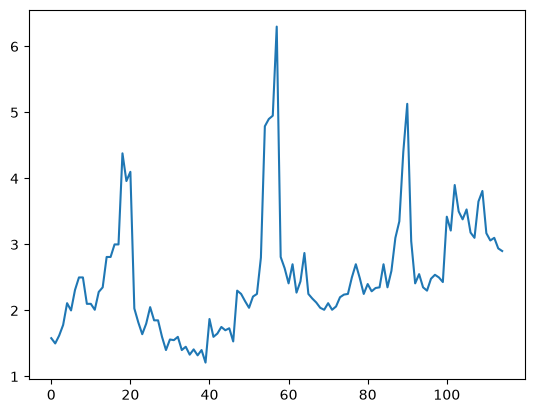

In [4]:
plt.plot(cutix_end_month_df['close_price'])
plt.show()

In [5]:
cutix_end_month_df['returns']=cutix_end_month_df['close_price'].pct_change()*100
cutix_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45416,CUTIX,2017-01-31,1.58,1.58,14200,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47238,CUTIX,2017-02-28,1.50,1.50,19000,2026-04-08T02:44:45.006295+00:00,2,1,2017,-5.063291
2,49354,CUTIX,2017-03-31,1.62,1.62,10000,2026-04-08T02:45:42.281198+00:00,3,1,2017,8.000000
3,51181,CUTIX,2017-04-28,1.78,1.78,151000,2026-04-08T02:51:55.619599+00:00,4,2,2017,9.876543
4,53104,CUTIX,2017-05-31,2.11,2.11,100500,2026-04-08T02:52:57.421655+00:00,5,2,2017,18.539326
...,...,...,...,...,...,...,...,...,...,...,...
110,35283,CUTIX,2026-03-31,3.17,3.17,6164245,2026-03-31T15:00:02.085058+00:00,3,1,2026,-16.797900
111,281110,CUTIX,2026-04-30,3.06,3.06,4612414,2026-04-30T15:00:02.170664+00:00,4,2,2026,-3.470032
112,284176,CUTIX,2026-05-29,3.10,3.10,5257210,2026-05-29T15:00:02.455558+00:00,5,2,2026,1.307190
113,294105,CUTIX,2026-06-30,2.94,2.94,6110290,2026-06-30T15:10:03.08168+00:00,6,2,2026,-5.161290


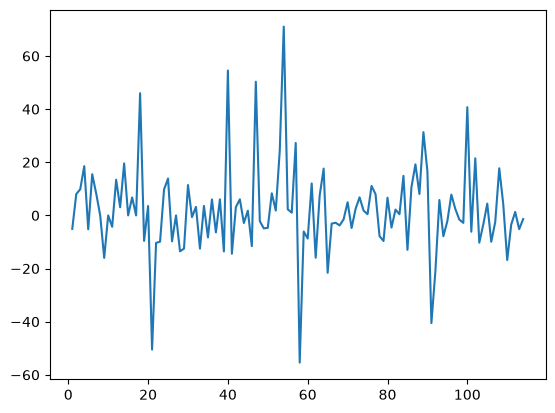

In [6]:
plt.plot(cutix_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(cutix_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-4.466983336473571), np.float64(0.00022549089656392763), 8, 105, {'1%': np.float64(-3.4942202045135513), '5%': np.float64(-2.889485291005291), '10%': np.float64(-2.5816762131519275)}, np.float64(857.3481643751187))
stationary


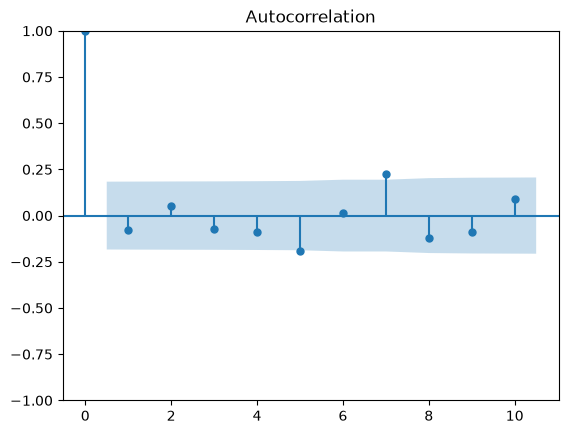

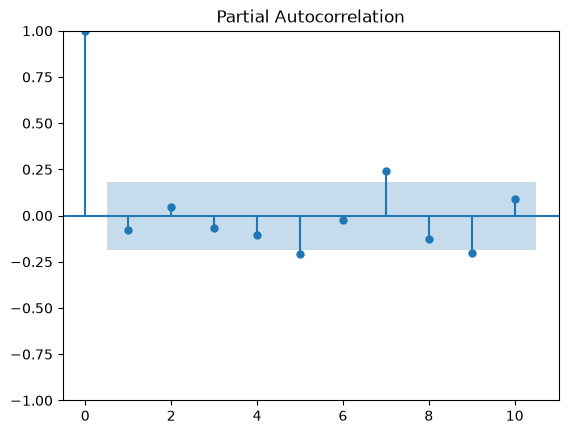

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(cutix_end_month_df['returns'].dropna(), lags=10)
plot_pacf(cutix_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=cutix_end_month_df['close_price'][:-10]
test=cutix_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -121.99220996012242]
[0, 0, 0, 0, 0, 1, -76.12995242035484]
[0, 0, 0, 0, 0, 2, -43.71315995857363]
[0, 0, 0, 0, 1, 0, -7.45335249930446]
[0, 0, 0, 0, 1, 1, -11.384150763242921]
[0, 0, 0, 0, 1, 2, -10.038453470973536]
[0, 0, 0, 0, 2, 0, -8.675067235368623]
[0, 0, 0, 0, 2, 1, -7.02878403142476]
[0, 0, 0, 0, 2, 2, -5.466510162235105]
[0, 0, 0, 1, 0, 0, -12.084502597124116]
[0, 0, 0, 1, 0, 1, -11.583101328812798]
[0, 0, 0, 1, 0, 2, -11.173743231980318]
[0, 0, 0, 1, 1, 0, -9.564113760890352]
[0, 0, 0, 1, 1, 1, -11.182934745908698]
[0, 0, 0, 1, 1, 2, -14.17171187495882]
[0, 0, 0, 1, 2, 0, -8.826190348272036]
[0, 0, 0, 1, 2, 1, -9.203027246560993]
[0, 0, 0, 1, 2, 2, -5.450990567333614]
[0, 0, 0, 2, 0, 0, -10.674582612620712]
[0, 0, 0, 2, 0, 1, -11.794662086463243]
[0, 0, 0, 2, 0, 2, -14.704522443716371]
[0, 0, 0, 2, 1, 0, -9.552603666033786]
[0, 0, 0, 2, 1, 1, -8.229255405682641]
[0, 0, 0, 2, 1, 2, -7.67715110001285]
[0, 0, 0, 2, 2, 0, -30.44366922764449]
[0, 0, 0, 2, 2, 1,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-2001.351614
654,2,2,0,0,2,0,-1155.211681
672,2,2,0,2,2,0,-1046.957648
420,1,2,0,1,2,0,-1021.245808
429,1,2,0,2,2,0,-880.886056
...,...,...,...,...,...,...,...
171,0,2,0,1,0,0,0.123657
461,1,2,2,0,0,2,0.128052
163,0,2,0,0,0,1,0.189937
180,0,2,0,2,0,0,0.269921


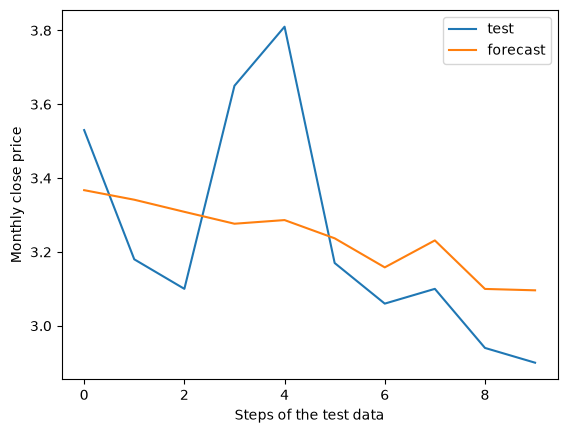

r2_score:  0.298413140258716
rmse:  0.24601156246957603
description:  count    115.000000
mean       2.511739
std        0.899766
min        1.210000
25%        2.005000
50%        2.310000
75%        2.885000
max        6.300000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=cutix_end_month_df['close_price'][:-10]
y_test=cutix_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', cutix_end_month_df.close_price.describe())

We will work with this.

In [15]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=custodian_end_month_df['returns'].dropna()[:-10]
test=custodian_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.13555205532497716]
[0, 0, 0, 0, 0, 1, -0.19732521303048034]
[0, 0, 0, 0, 0, 2, -0.28065638321973174]
[0, 0, 0, 0, 1, 0, -1.2569585921406317]
[0, 0, 0, 0, 1, 1, -0.7836723739356162]
[0, 0, 0, 0, 1, 2, -0.6846425088196693]
[0, 0, 0, 0, 2, 0, -2.8199890106827765]
[0, 0, 0, 0, 2, 1, -1.579788285256333]
[0, 0, 0, 0, 2, 2, -1.585772004512735]
[0, 0, 0, 1, 0, 0, -0.2779207535822219]
[0, 0, 0, 1, 0, 1, -0.2745430619496274]
[0, 0, 0, 1, 0, 2, -0.2713824889884475]
[0, 0, 0, 1, 1, 0, -0.9868310640445144]
[0, 0, 0, 1, 1, 1, -0.6576768218379423]
[0, 0, 0, 1, 1, 2, -0.6578578226881036]
[0, 0, 0, 1, 2, 0, -2.159027741961052]
[0, 0, 0, 1, 2, 1, -1.5264148387354624]
[0, 0, 0, 1, 2, 2, -1.4832654098024904]
[0, 0, 0, 2, 0, 0, -0.2730391596966293]
[0, 0, 0, 2, 0, 1, -0.27031638164372374]
[0, 0, 0, 2, 0, 2, -0.21697619899396559]
[0, 0, 0, 2, 1, 0, -0.9104903341134154]
[0, 0, 0, 2, 1, 1, -0.6577054358136083]
[0, 0, 0, 2, 1, 2, -0.6618668117458439]
[0, 0, 0, 2, 2, 0, -2.146781760375256]

In [16]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-167.312685
177,0,2,0,1,2,0,-157.386197
186,0,2,0,2,2,0,-116.024908
179,0,2,0,1,2,2,-108.021794
169,0,2,0,0,2,1,-106.859880
...,...,...,...,...,...,...,...
108,0,1,1,0,0,0,-0.013402
432,1,2,1,0,0,0,-0.004140
324,1,1,0,0,0,0,-0.003946
513,2,0,1,0,0,0,-0.002987


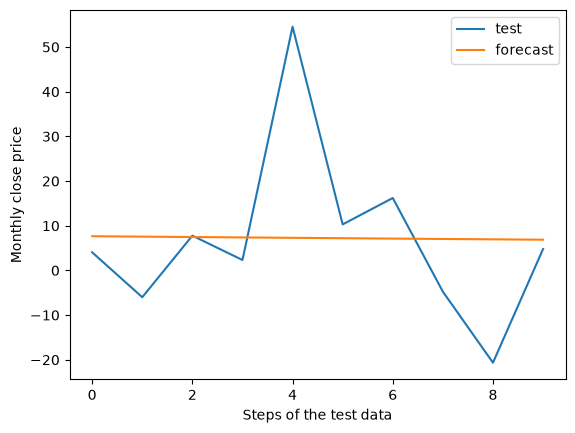

r2_score:  0.003217000568169981
rmse:  18.58370249116093
description:  count    97.000000
mean      3.291938
std      11.444408
min     -20.662651
25%      -2.542373
50%       0.793651
75%       8.256881
max      54.545455
Name: returns, dtype: float64


In [17]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=custodian_end_month_df['returns'].dropna()[:-10]
y_test=custodian_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', custodian_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
